# Análisis End-to-End de Neurona Individual

In [1]:
%load_ext autoreload
%autoreload 2

import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('.'))

from scripts.utils import (
    _cargar_datos_neurona,
    preparar_datos_posicion,
    preparar_datos_head_direction,
    preparar_datos_mirada,
    firing_map
)

from scripts.utils.angulo_preferido import (
    analizar_sintonizacion_perspectiva_continua,
    evaluar_confianza_sintonizacion_perspectiva
)

from scripts.utils.cross_validation import (
    generate_all_splits,
    cross_validate_gam_grid,
    select_best_1se_gam,
    retrain_best_gam,
    poisson_nll_per_sample,
    null_model_nll,
    pseudo_r2_mcfadden
)


## 1. Configuración de Parámetros

In [2]:
sesion = 2
tetrodo = 2
neurona = 3
bin_size_sec = 0.1

## 2. Firing Map

-> graficando s=2, t=2, c=3. disparos: 206


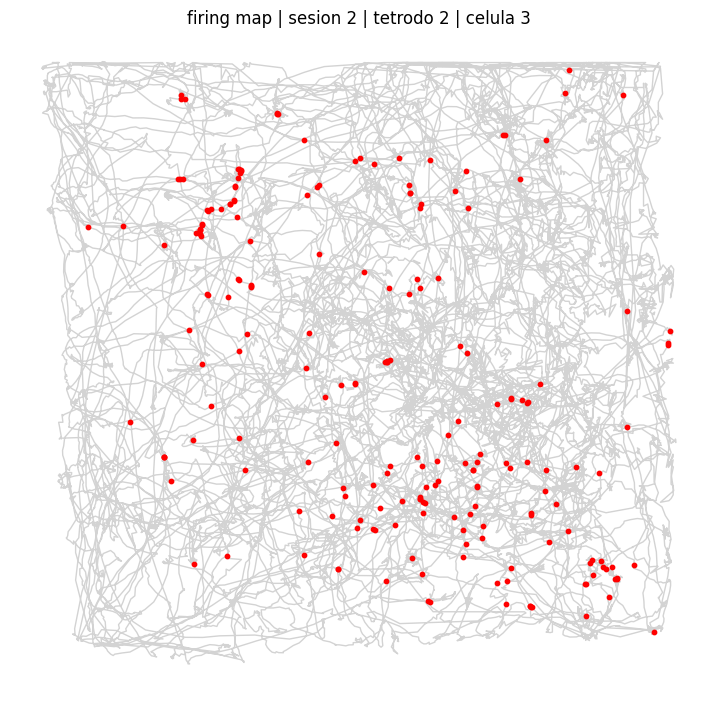

In [3]:
firing_map(sesion, tetrodo, neurona)
plt.show()

## 3. Análisis de Viewpoint

In [4]:
# ---- Parámetros de la grilla y análisis ----
grid_res = 25

x_bins, y_bins, ang_bins_rad, spikes_gaze = preparar_datos_mirada(sesion, tetrodo, neurona, bin_size_sec)

res_persp = analizar_sintonizacion_perspectiva_continua(
    x_bins, y_bins, ang_bins_rad, spikes_gaze, tiempos_bin=bin_size_sec, grid_res=grid_res
)
x_best_p, y_best_p = res_persp['best_coord']
print(f"Coordenada Óptima de Perspectiva: X={x_best_p:.2f}, Y={y_best_p:.2f}")
print(f"Amplitud de Proyección Máxima: {res_persp['persp_indx']:.4f} Hz")

# res_sig = evaluar_confianza_sintonizacion_perspectiva(
#     x_bins, y_bins, ang_bins_rad, spikes_gaze, tiempos_bin=bin_size_sec, grid_res=grid_res, n_shifts=100, min_shift_sec=10.0
# )
# print(f"Z-score: {res_sig['z_score']:.2f}, Significativo: {res_sig['confianza_significativa']}")

Coordenada Óptima de Perspectiva: X=59.72, Y=3.78
Amplitud de Proyección Máxima: 0.1425 Hz


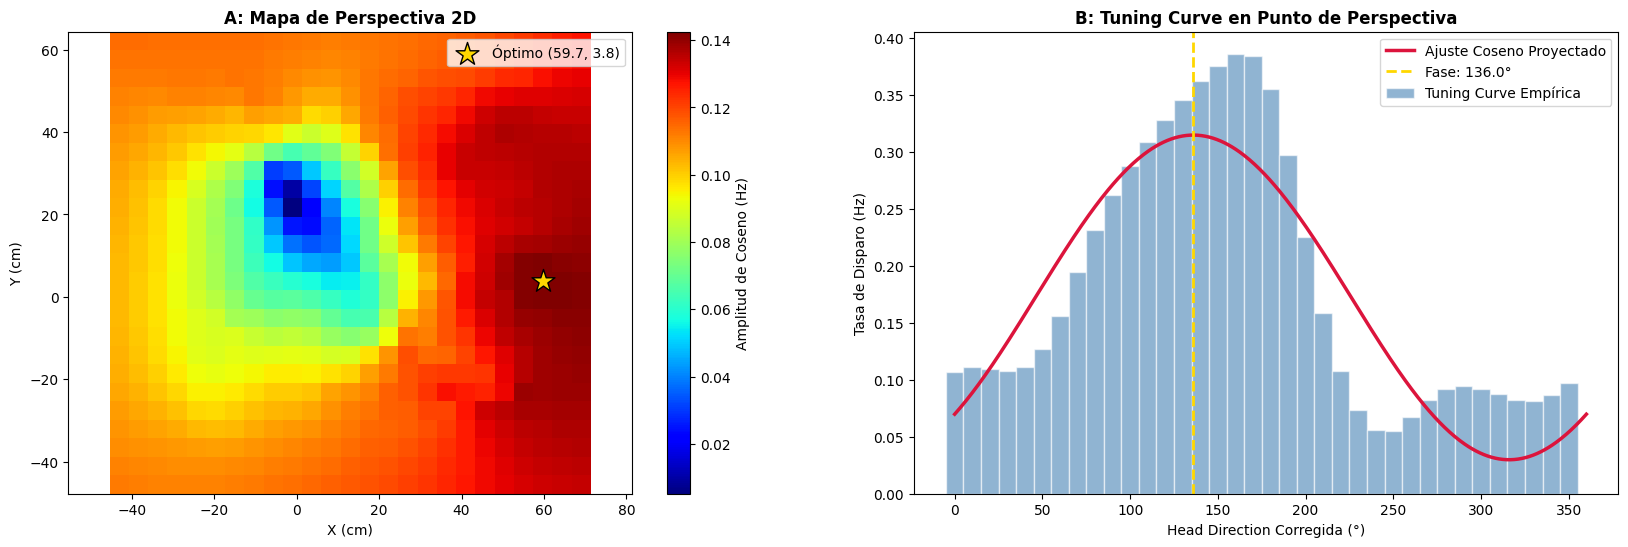

In [5]:
# # ---- Generar visualización. 3 paneles ----
# fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# ---- Generar visualización. 2 paneles ----
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Panel 1: Heatmap de Perspectiva
ax1 = axes[0]
XX_p = res_persp['XX']
YY_p = res_persp['YY']
map_p_matrix = res_persp['map_p_matrix']
mesh1 = ax1.pcolormesh(XX_p, YY_p, map_p_matrix, cmap='jet', shading='nearest')
fig.colorbar(mesh1, ax=ax1, label='Amplitud de Coseno (Hz)')
ax1.scatter(x_best_p, y_best_p, color='gold', marker='*', s=300, edgecolor='black', zorder=10, label=f'Óptimo ({x_best_p:.1f}, {y_best_p:.1f})')
ax1.set_title('A: Mapa de Perspectiva 2D', fontweight='bold')
ax1.set_xlabel('X (cm)')
ax1.set_ylabel('Y (cm)')
ax1.axis('equal')
ax1.legend()

# Panel 2: Tuning Curve Corregida y Modelo de Coseno Ajustado
ax2 = axes[1]
hdbins_deg = np.degrees(res_persp['hdbins'])
tuning_curve_best = res_persp['tuning_curve_best']
ax2.bar(hdbins_deg, tuning_curve_best, width=360/36, alpha=0.6, color='steelblue', edgecolor='white', label='Tuning Curve Empírica')

# Graficar modelo ajustado de coseno
x_fit = np.linspace(0, 360, 500)
rate_mean = np.mean(spikes_gaze) / bin_size_sec
y_fit = rate_mean + res_persp['persp_indx'] * np.cos(np.radians(x_fit) - res_persp['theta0'])
y_fit = np.clip(y_fit, 0, None)
ax2.plot(x_fit, y_fit, color='crimson', linewidth=2.5, label='Ajuste Coseno Proyectado')
ax2.axvline(np.degrees(res_persp['theta0']), color='gold', linestyle='--', linewidth=2, label=f'Fase: {np.degrees(res_persp["theta0"]):.1f}°')
ax2.set_xlabel('Head Direction Corregida (°)')
ax2.set_ylabel('Tasa de Disparo (Hz)')
ax2.set_title('B: Tuning Curve en Punto de Perspectiva', fontweight='bold')
ax2.legend()

# # Panel 3: Distribución Nula mediante Spike Shifting
# ax3 = axes[2]
# sns.histplot(res_sig['shuffled_persp_indxs'], ax=ax3, color='gray', alpha=0.6, kde=True, label='Shuffled (Nula)')
# ax3.axvline(res_sig['original_persp_indx'], color='red', linestyle='--', linewidth=2.5,
#             label=f'Original: {res_sig["original_persp_indx"]:.4f} Hz\np={res_sig["p_value"]:.3f} (Z={res_sig["z_score"]:.1f})')
# ax3.set_title('C: Test de Control Spike Shifting', fontweight='bold')
# ax3.set_xlabel('Amplitud de Proyección Máxima (Hz)')
# ax3.set_ylabel('Frecuencia')
# ax3.legend()

# plt.suptitle(f's={sesion} t={tetrodo} c={neurona}', fontsize=15, fontweight='bold', y=0.98)
# plt.tight_layout()
# plt.show()

## 4. Preparación de Datos para GAMs

In [6]:
# Datos para Head Direction
ang_bins_deg, spikes_hd = preparar_datos_head_direction(sesion, tetrodo, neurona, bin_size_sec=bin_size_sec)
hd_rad = np.radians(ang_bins_deg)

# Datos corregidos para Viewpoint
dy = y_best_p - y_bins
dx = x_best_p - x_bins
ang_hacia_punto = np.arctan2(dy, dx)
theta_corrected = np.mod(ang_bins_rad - ang_hacia_punto, 2 * np.pi)
distances = np.sqrt((x_bins - x_best_p)**2 + (y_bins - y_best_p)**2)

# Consolidamos X_cv asumiendo el mismo tamaño de arrays
X_cv = np.column_stack((x_bins, y_bins, theta_corrected, distances, hd_rad))
Y_cv = spikes_gaze

folds, held_out_idx, train_pool_idx, roles = generate_all_splits(
    n_muestras=len(X_cv),
    bin_size_sec=bin_size_sec,
    block_size_sec=60,
    n_folds=5,
    buffer_sec=2
)

X_pool, Y_pool = X_cv[train_pool_idx], Y_cv[train_pool_idx]
X_held, Y_held = X_cv[held_out_idx], Y_cv[held_out_idx]

splines_a_probar = [9]
lambdas_a_probar = np.logspace(-1, 1, 7)

## 5. Cross-Validation: Posición, Viewpoint, Joint (Pos + View + Distancia)

In [7]:
# Diccionario con configuraciones de cada modelo
# cols indica las columnas en X_cv que se extraen para entrenar
modelos_a_evaluar = {
    'Pos': {'cols': [0, 1], 'type': 'pos'},
    'Viewpoint': {'cols': [2], 'type': 'view_angle'},
    'HD': {'cols': [4], 'type': 'view_angle'},
    'Pos + View': {'cols': [0, 1, 2], 'type': 'pos_view_angle'},
    'Pos + HD': {'cols': [0, 1, 4], 'type': 'pos_hd'},
    'Pos + Dist': {'cols': [0, 1, 3], 'type': 'pos_dist'},
    'Pos + View + Dist': {'cols': [0, 1, 2, 3], 'type': 'pos_view_angle_dist'},
    'Pos + HD + Dist': {'cols': [0, 1, 4, 3], 'type': 'pos_hd_dist'}
}

resultados_modelos = {}

for nombre, config in modelos_a_evaluar.items():
    print(f"\n--- Evaluando modelo: {nombre} ---")
    cols = config['cols']
    m_type = config['type']
    
    # Extraemos solo las columnas relevantes
    X_subset = X_cv[:, cols]
    
    # 1. Validación cruzada en la grilla de hiperparámetros
    _, res_cv = cross_validate_gam_grid(X_subset, Y_cv, folds, splines_a_probar, lambdas_a_probar, model_type=m_type)
    
    # 2. Seleccionar el mejor hiperparámetro (Mínimo NLL puro, ignorando 1-SE)
    mejor_min, _, _ = select_best_1se_gam(res_cv)
    best_sp = int(mejor_min[0])
    best_lam = mejor_min[1]
    
    print(f"Mejor configuración (Min NLL): splines={best_sp}, lambda={best_lam:.4f}")
    
    # 3. Re-entrenar con todos los datos del pool de entrenamiento
    X_pool_subset = X_pool[:, cols]
    modelo_final = retrain_best_gam(X_pool_subset, Y_pool, best_sp, best_lam, model_type=m_type)
    
    # Guardamos los resultados
    resultados_modelos[nombre] = {
        'modelo': modelo_final,
        'cols': cols
    }



--- Evaluando modelo: Pos ---
sp= 9, lam= 0.1000000 | edof:  16.7145 | nll test: 0.08451120 (± 0.00865687)
sp= 9, lam= 0.2154435 | edof:  13.8024 | nll test: 0.08419428 (± 0.00865143)
sp= 9, lam= 0.4641589 | edof:  11.3254 | nll test: 0.08400941 (± 0.00864602)
sp= 9, lam= 1.0000000 | edof:   9.2715 | nll test: 0.08397345 (± 0.00864530)
sp= 9, lam= 2.1544347 | edof:   7.6133 | nll test: 0.08407853 (± 0.00864297)
sp= 9, lam= 4.6415888 | edof:   6.3196 | nll test: 0.08430014 (± 0.00863830)
sp= 9, lam=10.0000000 | edof:   5.3711 | nll test: 0.08458211 (± 0.00863328)
Mejor configuración (Min NLL): splines=9, lambda=1.0000

--- Evaluando modelo: Viewpoint ---
sp= 9, lam= 0.1000000 | edof:   7.4919 | nll test: 0.08265033 (± 0.00666240)
sp= 9, lam= 0.2154435 | edof:   7.0418 | nll test: 0.08271980 (± 0.00667504)
sp= 9, lam= 0.4641589 | edof:   6.5988 | nll test: 0.08276950 (± 0.00667507)
sp= 9, lam= 1.0000000 | edof:   6.1760 | nll test: 0.08279652 (± 0.00667122)
sp= 9, lam= 2.1544347 | edof:

Modelo Nulo (NLL): 0.1033

Pos                  | NLL: 0.0980 | Pseudo R²: 0.0509
Viewpoint            | NLL: 0.1000 | Pseudo R²: 0.0322
HD                   | NLL: 0.0999 | Pseudo R²: 0.0325
Pos + View           | NLL: 0.0929 | Pseudo R²: 0.1001
Pos + HD             | NLL: 0.0934 | Pseudo R²: 0.0958
Pos + Dist           | NLL: 0.0978 | Pseudo R²: 0.0530
Pos + View + Dist    | NLL: 0.0928 | Pseudo R²: 0.1018
Pos + HD + Dist      | NLL: 0.0932 | Pseudo R²: 0.0981


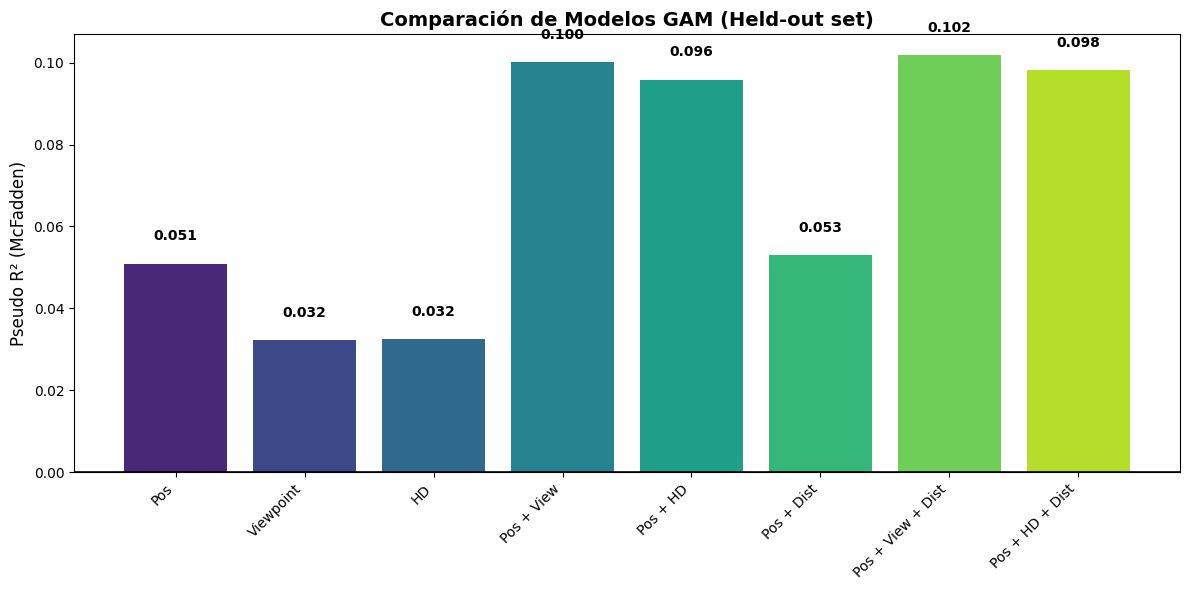

In [8]:
# ---- Evaluación Final en Held-out (Pseudo R²) ----
nll_null = null_model_nll(Y_pool, Y_held)
print(f"Modelo Nulo (NLL): {nll_null:.4f}\n")

r2_scores = {}

for nombre, datos in resultados_modelos.items():
    modelo = datos['modelo']
    cols = datos['cols']
    
    # Extraemos los datos del held-out set para predecir
    X_held_subset = X_held[:, cols]
    
    # Predicción (mu)
    mu_pred = modelo.predict(X_held_subset)
    
    # Calculamos NLL y McFadden's Pseudo R²
    nll_model = poisson_nll_per_sample(Y_held, mu_pred)
    r2 = pseudo_r2_mcfadden(nll_model, nll_null)
    
    r2_scores[nombre] = r2
    print(f"{nombre:<20} | NLL: {nll_model:.4f} | Pseudo R²: {r2:.4f}")

# ---- Gráfico de Barras ----
plt.figure(figsize=(12, 6))
nombres = list(r2_scores.keys())
valores_r2 = list(r2_scores.values())

bars = plt.bar(nombres, valores_r2, color=sns.color_palette("viridis", len(nombres)))
plt.axhline(0, color='black', linewidth=1.2)
plt.ylabel('Pseudo R² (McFadden)', fontsize=12)
plt.title('Comparación de Modelos GAM (Held-out set)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')

# Añadir valores arriba de las barras
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f'{yval:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()
